In [14]:
import torch
from captum.attr import DeepLiftShap, IntegratedGradients
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
#from dataset import load_data, sample_test_data
import pandas as pd
from collections import defaultdict
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict


In [2]:
from microbiome_model.data.dataset import DataProcessor, Arguments
from microbiome_model.data.dataset_sparse import collate_fn as sparse_collate_fn
from microbiome_model.models.orig import BasicRegressor
from microbiome_model.eval.evaluate import predict
import json
import torch.nn as nn
from torch.optim import AdamW
import os

In [3]:
donor_ids = ['D19','D7','D8','D22','D13','D15','D28','D10','D17','D11','D4','D26','D23','D29','D27','D20','D6',
 'D25','D30','D5','D21','D18','D14','D12','D24','D9','D16']
indoor_ids = ['D7', 'D5', 'D9', 'D14', 'D16', 'D18', 'D20', 'D22', 'D24', 'D26',
       'D28', 'D30']
outdoor_uncaged = ['D6', 'D10', 'D12']
outdoor_caged = ['D8', 'D4', 'D11', 'D13', 'D15', 'D17', 'D19', 'D21', 'D23', 'D25',
       'D27', 'D29']
all_outdoor = outdoor_uncaged + outdoor_caged

In [7]:
len(donor_ids), len(indoor_ids), len(outdoor_uncaged), len(outdoor_caged), len(all_outdoor)

(27, 12, 3, 12, 15)

In [8]:
class WrappedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, embeddings, abundances, features, env, masks=None):
        outputs = self.model(embeddings, abundances, masks, features, env=env)[0]
        return outputs

In [9]:
def computer_attributions(wrapped_model, test_loader, donor_id, attribution_method="IG", device='cuda'):
    if attribution_method == "Shap":
        attributor = DeepLiftShap(wrapped_model)
    elif attribution_method == "IG":
        attributor = IntegratedGradients(wrapped_model, multiply_by_inputs=True)
    else:
        raise ValueError("Unsupported attribution method. Use 'DeepLiftShap' or 'IG'.")

    all_attr_embeddings = []
    all_attr_abundances = []
    all_attr_features = []
    all_attr_env = []
    all_seq_ids = []
    all_sample_ids = []

    for batch in tqdm(test_loader):
        embeddings = batch['embeddings'].to(device).requires_grad_()
        abundances = batch['abundances'].to(device).requires_grad_() / 1e4
        masks = batch['masks'].to(device)
        sample_ids = batch['SampleID']
        seq_ids = batch['seqs_ids']
        features = batch['season'].to(device, dtype=torch.float32).requires_grad_()
        env = batch['env'].to(device, dtype=torch.float32).requires_grad_()
        all_seq_ids.append(seq_ids)
        all_sample_ids.append(sample_ids)

        baseline_embed = torch.zeros_like(embeddings)
        baseline_abund = torch.zeros_like(abundances)
        baseline_features = torch.zeros_like(features)
        #baseline_env = torch.zeros_like(env)
        ### with 0.5 
        baseline_env = torch.full_like(env, 0.5)

        inputs = (embeddings, abundances, features, env)
        baselines = (baseline_embed, baseline_abund, baseline_features, baseline_env)

        attributions = attributor.attribute(
            inputs=inputs,
            baselines=baselines,
            additional_forward_args=(masks,),
            n_steps=100
        )
        
        all_attr_embeddings.append(attributions[0].detach().cpu())
        all_attr_abundances.append(attributions[1].detach().cpu())
        all_attr_features.append(attributions[2].detach().cpu())
        all_attr_env.append(attributions[3].detach().cpu())

    return all_attr_embeddings, all_attr_abundances, all_attr_features, all_attr_env, all_seq_ids, all_sample_ids

In [6]:
base_dir = "/s/chromatin/o/nobackup/Saira/Microbiome_Project/"
data_dir = os.path.join(base_dir, "data/new_data")
res = "../results/all_data_ST_pe_3/"
metadata_file = os.path.join(data_dir, "combined_metadata_merged.tsv")


In [10]:
res = "heldout_orig_softplus/"
res = "finetune_dnabert_results/more_encoder_layers_filtered_biom_mae_bigN_nonzero_asvs/"
res = "../results/multitask_all_nope_bimonth_env_features/"
res = "../results/all_data_ST_pe_3/"
multitask = True

best_runs = {}
biom_file = os.path.join(base_dir,"process_data_all/exported-feature-table/feature-table.biom")
sheds_file = os.path.join(data_dir, "metadata_sheds.tsv")
embedding_path = os.path.join(base_dir, "data/embeddings/all_data.h5")
all_samples_asv_importance = {}

for donor_id in all_outdoor:  # or indoor_ids
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    avg_mae = 0
    best_mae = 1000
    runs = 3
    best_i = 0
    for i in range(1, runs+1):
        dir = f"{res}/{donor_id}/run_{i}/"
                    
        with open(dir + 'res.json') as f:
            config = json.load(f)
            mae = float(config['best_mae'])
            if mae < best_mae:
                best_mae = mae
                best_run = dir
                best_i = i
    
    if os.path.exists(best_run + "attributions_asv_100.json"):
        print(f"Attributions already exist for donor {donor_id}, run {best_i}. Skipping...")
        best_runs[donor_id] = best_i
        continue
                
    model_files = best_run + "model.pt"
    print(f"Best run: {best_run}", best_mae)
    # Instantiate and load model
    model = BasicRegressor(input_dim=512, hidden_dim=512,num_heads=4, num_layers=2, pe=False) #768
    model.load_state_dict(torch.load(model_files, map_location=device))
    
    args = Arguments(
            biom_file=biom_file,
            metadata_file=metadata_file,
            tree_path=None,
            embedding_file=embedding_path,
            embedding="DNABERT",
            heldout=donor_id,
            sort_asvs=True, 
                )
        
        # Load Data
    data_processor = DataProcessor(args)
        # Assuming load_data handles the splitting based on 'heldout' arg
    data_processor.load_data(multitask=multitask, column="bi_month_name")
        
    test_dataset = data_processor.sample_test_data()
    if len(test_dataset) == 0:
            print(f"Warning: No test data found for donor {donor_id}")
            continue
            
    test_loader = torch.utils.data.DataLoader(
            test_dataset, 
            batch_size=2, 
            shuffle=False, 
            num_workers=0, 
            collate_fn=sparse_collate_fn
        )
    

    # Move model to the correct device
    model = model.to(device)
    # Set up attribution method
    model.eval()
    wrapped_model = WrappedModel(model).to(device)
    all_attr_embeddings, all_attr_abundances, all_attr_features, all_attr_env, all_seq_ids, all_sample_ids = computer_attributions(
        wrapped_model, test_loader, donor_id, attribution_method="IG", device=device
    )

    per_sample_asv_importance = {}
    per_sample_abundance_importance = {}
    per_sample_feature_importance = {}
    per_sample_env_importance = {}

    for i in range(len(all_attr_embeddings)):
        sample_ids = all_sample_ids[i]
        per_batch_seq_ids = all_seq_ids[i]
        
        for j in range(all_attr_embeddings[i].shape[0]):
            sample_id = sample_ids[j]
            
            # --- ASV embedding attributions ---
            per_sample_asv_importance.setdefault(sample_id, {})
            if sample_id not in all_samples_asv_importance:
                all_samples_asv_importance[sample_id] = {}
            
            per_sample_seq_ids = per_batch_seq_ids[j]
            attr = all_attr_embeddings[i][j].abs().mean(dim=-1).numpy()
            attr_thresh = np.max(attr) * 0.70
            for k in range(len(per_sample_seq_ids)):
                seq_id = per_sample_seq_ids[k]
                if attr[k] < attr_thresh:
                    continue
                
                per_sample_asv_importance[sample_id][seq_id] = float(attr[k])
                all_samples_asv_importance[sample_id][seq_id] = float(attr[k])
            
            # --- Abundance attributions (per ASV) ---
            per_sample_abundance_importance.setdefault(sample_id, {})
            abund_attr = all_attr_abundances[i][j].abs().squeeze(-1).numpy()  # [L]
            for k in range(len(per_sample_seq_ids)):
                seq_id = per_sample_seq_ids[k]
                per_sample_abundance_importance[sample_id][seq_id] = float(abund_attr[k])
            
            # --- Feature attributions (season/bi-month) ---
            feat_attr = all_attr_features[i][j].abs().numpy()  # [6]
            per_sample_feature_importance[sample_id] = feat_attr.tolist()
            
            # --- Env attribution (indoor/outdoor) ---
            env_attr = all_attr_env[i][j].abs().item()
            per_sample_env_importance[sample_id] = env_attr

    # Save all results
    with open(f"{res}/{donor_id}/run_{best_i}/attributions_asv_100.json", 'w') as f:
        json.dump(per_sample_asv_importance, f, indent=4)

    with open(f"{res}/{donor_id}/run_{best_i}/attributions_abundance_100.json", 'w') as f:
        json.dump(per_sample_abundance_importance, f, indent=4)

    with open(f"{res}/{donor_id}/run_{best_i}/attributions_features_100.json", 'w') as f:
        json.dump(per_sample_feature_importance, f, indent=4)

    with open(f"{res}/{donor_id}/run_{best_i}/attributions_env_100.json", 'w') as f:
        json.dump(per_sample_env_importance, f, indent=4)
    
    best_runs[donor_id] = best_i
    
    
    
    

Attributions already exist for donor D6, run 3. Skipping...
Attributions already exist for donor D10, run 3. Skipping...
Attributions already exist for donor D12, run 2. Skipping...
Attributions already exist for donor D8, run 1. Skipping...
Attributions already exist for donor D4, run 2. Skipping...
Attributions already exist for donor D11, run 3. Skipping...
Attributions already exist for donor D13, run 1. Skipping...
Attributions already exist for donor D15, run 1. Skipping...
Attributions already exist for donor D17, run 3. Skipping...
Attributions already exist for donor D19, run 1. Skipping...
Attributions already exist for donor D21, run 2. Skipping...
Attributions already exist for donor D23, run 2. Skipping...
Attributions already exist for donor D25, run 1. Skipping...
Attributions already exist for donor D27, run 2. Skipping...
Attributions already exist for donor D29, run 1. Skipping...


In [6]:
taxonomy_df = pd.read_csv("../../process_data_all/taxonomy/taxonomy.tsv", sep="\t")

In [7]:
taxonomy_df.head(5)

,Feature ID,Taxon,Confidence
0,AAAAAAGGATGCAAGCATTACCCAGAATTATTGGGTGTAAAGTGTC...,d__Bacteria; p__Cyanobacteriota; c__Chloroplas...,0.994702
1,AAACGTAGGGTGCAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGA...,d__Bacteria; p__Bacillota_A_368345; c__Clostri...,1.000000
2,AAAGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCA...,d__Bacteria; p__Pseudomonadota; c__Gammaproteo...,0.992151
3,AAAGTAGGGGGCCAGCGTTGCTCGGAATTACTGGGCGTAAAGGGTC...,d__Bacteria; p__Acidobacteriota; c__Terriglobi...,0.881636
4,AAAGTAGGGTGCGAGCGTTGTCCGGAATTATTGGGCGTAAAGAGCT...,d__Bacteria; p__Actinomycetota; c__Actinomycet...,0.994381


Used 385 indoor samples across 12 donors


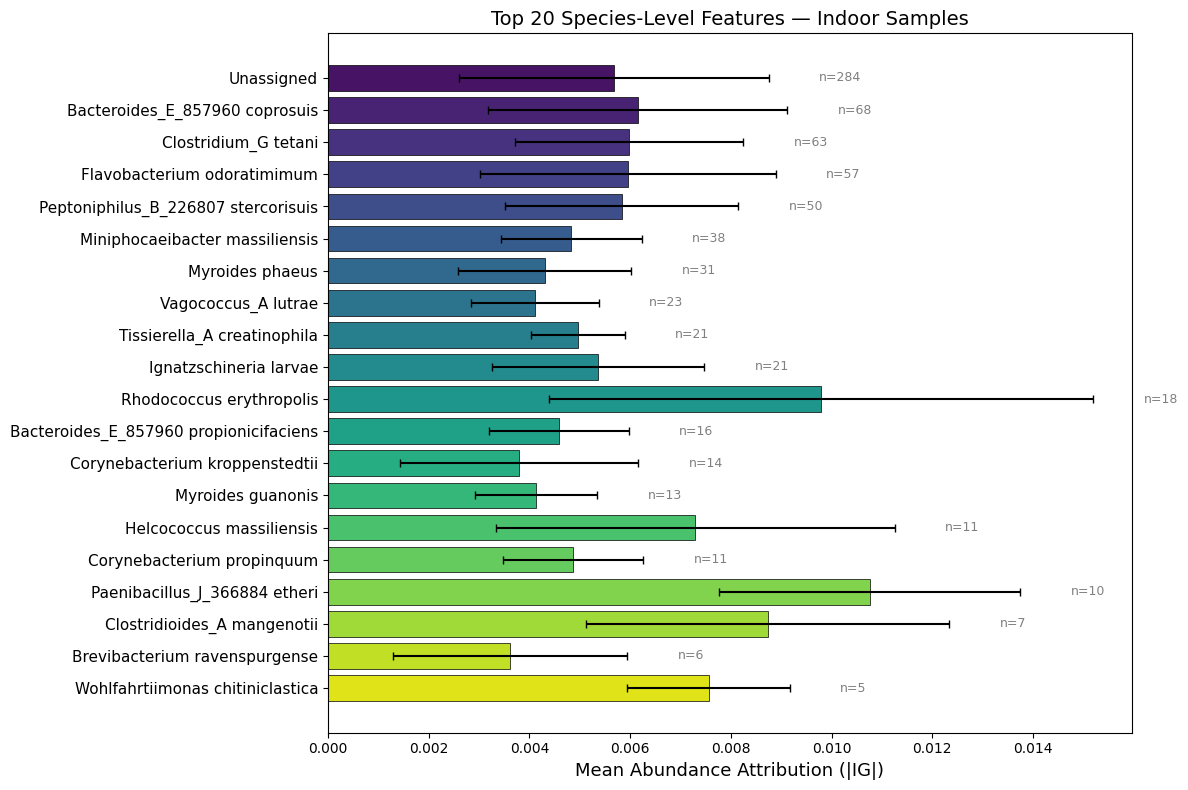

In [10]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict


def aggregate_attributions_by_taxonomy(
    donor_ids,
    res_dir,
    taxonomy_file,
    metadata_file,
    best_runs,  # dict: donor_id -> best_i
    tax_level="genus",  # "phylum", "class", "order", "family", "genus", "species"
    top_n=20,
    env_filter="outdoor",  # "indoor" or "outdoor" or None for all
):
    """
    Aggregate abundance attributions across donors, map to taxonomy, and plot.
    """
    
    # Load taxonomy mapping: seq_id -> full taxonomy string
    tax_df = pd.read_csv(taxonomy_file, sep="\t")
    # Assumes columns like: Feature ID, Taxon (or adjust to your format)
    seq_to_taxon = dict(zip(tax_df.iloc[:, 0], tax_df.iloc[:, 1]))
    
    # Load metadata to identify indoor/outdoor samples
    meta_df = pd.read_csv(metadata_file, sep="\t")
    meta_df["sample_name"] = meta_df["sample_name"].astype(str)
    if env_filter == "indoor":
        valid_samples = set(meta_df[meta_df["env"] == "indoor"]["sample_name"])
    elif env_filter == "outdoor":
        valid_samples = set(meta_df[meta_df["env"] != "indoor"]["sample_name"])
    else:
        valid_samples = set(meta_df["sample_name"])
    
    # Tax level index in semicolon-delimited taxonomy string
    # e.g., "k__Bacteria; p__Firmicutes; c__Clostridia; o__; f__; g__; s__"
    tax_level_map = {
        "kingdom": 0, "phylum": 1, "class": 2,
        "order": 3, "family": 4, "genus": 5, "species": 6
    }
    level_idx = tax_level_map[tax_level]
    
    def parse_taxonomy(taxon_str, level):
        """Extract taxonomy at a given level from semicolon-delimited string."""
        if pd.isna(taxon_str) or taxon_str is None:
            return "Unassigned"
        parts = [p.strip() for p in taxon_str.split(";")]
        if level < len(parts):
            name = parts[level].strip()
            # Remove prefix like "g__" 
            if "__" in name:
                name = name.split("__", 1)[1]
            return name if name else "Unassigned"
        return "Unassigned"
    
    # Accumulate: taxonomy_group -> list of attribution values
    tax_attributions = defaultdict(list)
    n_samples_used = 0
    
    for donor_id in donor_ids:
        best_i = best_runs[donor_id]
        attr_file = f"{res_dir}/{donor_id}/run_{best_i}/attributions_asv.json"
        
        try:
            with open(attr_file, 'r') as f:
                sample_attrs = json.load(f)
        except FileNotFoundError:
            print(f"Warning: {attr_file} not found, skipping {donor_id}")
            continue
        
        for sample_id, seq_attrs in sample_attrs.items():
            if sample_id not in valid_samples:
                continue
            
            n_samples_used += 1
            # Group attributions by taxonomy within this sample
            sample_tax_attrs = defaultdict(list)
            
            for seq_id, attr_val in seq_attrs.items():
                if seq_id is None or seq_id == "None":
                    continue
                taxon_str = seq_to_taxon.get(seq_id, None)
                tax_name = parse_taxonomy(taxon_str, level_idx)
                sample_tax_attrs[tax_name].append(abs(attr_val))
            
            # Average within sample first, then add to global
            for tax_name, vals in sample_tax_attrs.items():
                tax_attributions[tax_name].append(np.mean(vals))
    
    print(f"Used {n_samples_used} {env_filter} samples across {len(donor_ids)} donors")
    
    # Compute mean and std across samples for each taxonomy group
    results = []
    for tax_name, vals in tax_attributions.items():
        results.append({
            "taxonomy": tax_name,
            "mean_attribution": np.mean(vals),
            "std_attribution": np.std(vals),
            "n_samples": len(vals),
        })
    
    df = pd.DataFrame(results)
    df = df.sort_values("n_samples", ascending=False).head(top_n)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = sns.color_palette("viridis", len(df))
    bars = ax.barh(
        y=range(len(df)),
        width=df["mean_attribution"].values,
        xerr=df["std_attribution"].values,
        color=colors,
        edgecolor="black",
        linewidth=0.5,
        capsize=3,
    )
    
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["taxonomy"].values, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel("Mean Abundance Attribution (|IG|)", fontsize=13)
    ax.set_title(
        f"Top {top_n} {tax_level.capitalize()}-Level Features — {env_filter.capitalize()} Samples",
        fontsize=14,
    )
    
    # Annotate sample counts
    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(
            row["mean_attribution"] + row["std_attribution"] + 0.001,
            i,
            f"n={row['n_samples']}",
            va="center",
            fontsize=9,
            color="gray",
        )
    
    plt.tight_layout()
    return fig, df


# --- Usage ---
# donor_ids = indoor_ids  # or all_outdoor

# # Build best_runs dict from your res.json files
# best_runs = {}
# for donor_id in donor_ids:
#     best_mae = float('inf')
#     best_i = 1
#     for i in range(1, 4):
#         try:
#             with open(f"{res}/{donor_id}/run_{i}/res.json") as f:
#                 r = json.load(f)
#             if r["best_mae"] < best_mae:
#                 best_mae = r["best_mae"]
#                 best_i = i
#         except FileNotFoundError:
#             continue
#     best_runs[donor_id] = best_i

# fig_indoor, df_indoor = aggregate_attributions_by_taxonomy(
#     donor_ids=donor_ids,
#     res_dir=res,
#     taxonomy_file="../../process_data_all/taxonomy/taxonomy.tsv",
#     metadata_file=metadata_file,
#     best_runs=best_runs,
#     tax_level="species",
#     top_n=20,
#     env_filter="outdoor",
# )
# fig_indoor.savefig(f"{res}/outdoor_abundance_attributions_by_species.png", dpi=300, bbox_inches="tight")

donor_ids = indoor_ids  # or all_outdoor

fig_outdoor, df_outdoor = aggregate_attributions_by_taxonomy(
    donor_ids=donor_ids,
    res_dir=res,
    taxonomy_file="../../process_data_all/taxonomy/taxonomy.tsv",
    metadata_file=metadata_file,
    best_runs=best_runs,
    tax_level="species",
    top_n=20,
    env_filter="indoor",
)
fig_outdoor.savefig(f"{res}/indoor_abundance_attributions_by_species.png", dpi=300, bbox_inches="tight")

In [4]:
def get_best_taxon_label(taxon_str: str) -> str:
    """
    Return the finest resolved taxonomic name available, with rank prefix.
    e.g. 'g__Faecalibacterium' → 'Faecalibacterium (G)'
         an all-empty string   → 'Unassigned'
    """
    if pd.isna(taxon_str) or taxon_str is None:
        return "Unassigned"

    rank_abbrevs = ["K", "P", "C", "O", "F", "G", "S"]   # matches level 0-6
    parts = [p.strip() for p in taxon_str.split(";")]

    # Walk finest → coarsest
    for level in range(len(parts) - 1, -1, -1):
        part = parts[level]
        name = part.split("__", 1)[1].strip() if "__" in part else part.strip()
        if name and name.lower() not in ("", "unassigned"):
            abbrev = rank_abbrevs[level] if level < len(rank_abbrevs) else "?"
            return f"{name} ({abbrev})"

    return "Unassigned"

Used 547 outdoor samples across 15 donors


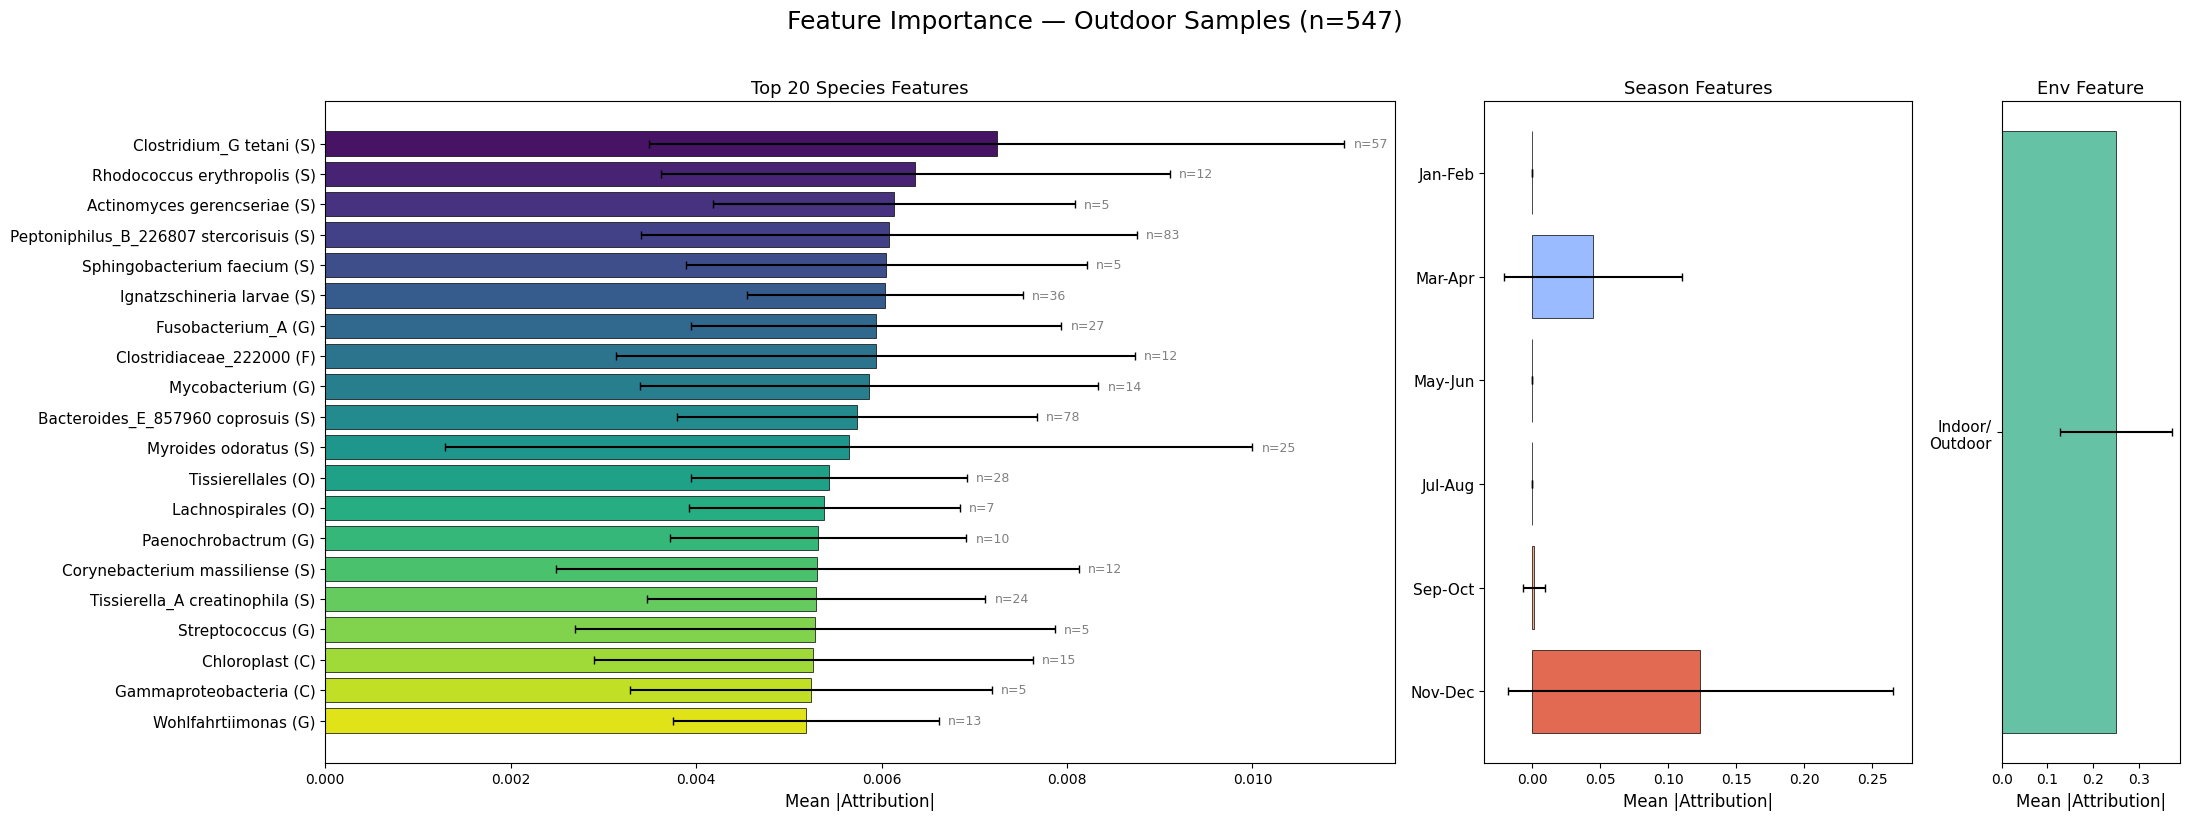

In [15]:
def aggregate_all_attributions(
    donor_ids,
    res_dir,
    taxonomy_file,
    metadata_file,
    best_runs,
    tax_level="genus",
    top_n=20,
    env_filter="outdoor",
    season_labels=None,  # e.g., ["Jan-Feb", "Mar-Apr", "May-Jun", "Jul-Aug", "Sep-Oct", "Nov-Dec"]
):
    # Load taxonomy
    tax_df = pd.read_csv(taxonomy_file, sep="\t")
    seq_to_taxon = dict(zip(tax_df.iloc[:, 0], tax_df.iloc[:, 1]))

    # Load metadata
    meta_df = pd.read_csv(metadata_file, sep="\t")
    meta_df["sample_name"] = meta_df["sample_name"].astype(str)
    if env_filter == "indoor":
        valid_samples = set(meta_df[meta_df["env"] == "indoor"]["sample_name"])
    elif env_filter == "outdoor":
        valid_samples = set(meta_df[meta_df["env"] != "indoor"]["sample_name"])
    else:
        valid_samples = set(meta_df["sample_name"])

    if season_labels is None:
        season_labels = ["Jan-Feb", "Mar-Apr", "May-Jun", "Jul-Aug", "Sep-Oct", "Nov-Dec"]

    tax_level_map = {
        "kingdom": 0, "phylum": 1, "class": 2,
        "order": 3, "family": 4, "genus": 5, "species": 6
    }
    level_idx = tax_level_map[tax_level]

    def parse_taxonomy(taxon_str, level):
        if pd.isna(taxon_str) or taxon_str is None:
            return "Unassigned"
        parts = [p.strip() for p in taxon_str.split(";")]
        if level < len(parts):
            name = parts[level].strip()
            if "__" in name:
                name = name.split("__", 1)[1]
            return name if name else "Unassigned"
        return "Unassigned"

    # Accumulators
    tax_attributions = defaultdict(list)
    env_attributions = []
    season_attributions = []  # list of arrays, each [n_seasons]
    n_samples_used = 0

    for donor_id in donor_ids:
        best_i = best_runs[donor_id]
        base_path = f"{res_dir}/{donor_id}/run_{best_i}"

        try:
            with open(f"{base_path}/attributions_asv_100.json") as f:
                asv_attrs = json.load(f)
            with open(f"{base_path}/attributions_abundance_100.json") as f:
                abund_attrs = json.load(f)
            with open(f"{base_path}/attributions_env_100.json") as f:
                env_attrs = json.load(f)
            with open(f"{base_path}/attributions_features_100.json") as f:
                feat_attrs = json.load(f)
        except FileNotFoundError as e:
            print(f"Warning: Missing file for {donor_id}: {e}")
            continue

        for sample_id in abund_attrs:
            if sample_id not in valid_samples:
                continue

            n_samples_used += 1

            # --- Abundance by taxonomy ---
            # sample_tax_attrs = defaultdict(list)
            # for seq_id, attr_val in abund_attrs[sample_id].items():
            #     if seq_id is None or seq_id == "None":
            #         continue
            #     taxon_str = seq_to_taxon.get(seq_id, None)
            #     tax_name = parse_taxonomy(taxon_str, level_idx)
            #     sample_tax_attrs[tax_name].append(abs(attr_val))

            # for tax_name, vals in sample_tax_attrs.items():
            #     tax_attributions[tax_name].append(np.mean(vals))
            sample_tax_attrs = defaultdict(list)
            for seq_id, attr_val in asv_attrs[sample_id].items():
                if seq_id is None or seq_id == "None":
                    continue
                taxon_str = seq_to_taxon.get(seq_id, None)
                tax_name  = get_best_taxon_label(taxon_str)   # ← changed
                sample_tax_attrs[tax_name].append(abs(attr_val))
                

            for tax_name, vals in sample_tax_attrs.items():
                tax_attributions[tax_name].append(np.mean(vals))

            # --- Env ---
            if sample_id in env_attrs:
                env_attributions.append(abs(env_attrs[sample_id]))

            # --- Season/bi-month ---
            if sample_id in feat_attrs:
                season_attributions.append(np.abs(feat_attrs[sample_id]))

    print(f"Used {n_samples_used} {env_filter} samples across {len(donor_ids)} donors")

    # === Build taxonomy df ===
    tax_results = []
    for tax_name, vals in tax_attributions.items():
        tax_results.append({
            "feature": tax_name,
            "category": "Microbiome",
            "mean_attribution": np.mean(vals),
            "std_attribution": np.std(vals),
            "n_samples": len(vals),
        })
    # filter if number of samples is too low (e.g., <5), then take top_n by mean attribution
    tax_results = [result for result in tax_results if result["n_samples"] >= 5]
    df_tax = pd.DataFrame(tax_results).sort_values("mean_attribution", ascending=False).head(top_n)

    # === Build env df ===
    df_env = pd.DataFrame([{
        "feature": "Indoor/Outdoor",
        "category": "Environment",
        "mean_attribution": np.mean(env_attributions),
        "std_attribution": np.std(env_attributions),
        "n_samples": len(env_attributions),
    }])

    # === Build season df ===
    season_arr = np.array(season_attributions)  # [n_samples, n_seasons]
    season_results = []
    for k, label in enumerate(season_labels):
        season_results.append({
            "feature": label,
            "category": "Season",
            "mean_attribution": np.mean(season_arr[:, k]),
            "std_attribution": np.std(season_arr[:, k]),
            "n_samples": len(season_arr),
        })
    df_season = pd.DataFrame(season_results)

    # === Combine all ===
    df_all = pd.concat([df_tax, df_season, df_env], ignore_index=True)

    # === Plot ===
    fig, axes = plt.subplots(1, 3, figsize=(22, 8),
                              gridspec_kw={"width_ratios": [3, 1.2, 0.5]})

    # --- Panel 1: Microbiome (taxonomy) ---
    ax1 = axes[0]
    colors_tax = sns.color_palette("viridis", len(df_tax))
    ax1.barh(
        y=range(len(df_tax)),
        width=df_tax["mean_attribution"].values,
        xerr=df_tax["std_attribution"].values,
        color=colors_tax, edgecolor="black", linewidth=0.5, capsize=3,
    )
    for i, (_, row) in enumerate(df_tax.iterrows()):
        ax1.text(
            row["mean_attribution"] + row["std_attribution"] + 0.0001,
            i-0.005,
            f"n={row['n_samples']}",
            va="center",
            fontsize=9,
            color="gray",
        )
    
    ax1.set_yticks(range(len(df_tax)))
    ax1.set_yticklabels(df_tax["feature"].values, fontsize=11)
    ax1.invert_yaxis()
    ax1.set_xlabel("Mean |Attribution|", fontsize=12)
    ax1.set_title(f"Top {top_n} {tax_level.capitalize()} Features", fontsize=13)

    # --- Panel 2: Season ---
    ax2 = axes[1]
    colors_season = sns.color_palette("coolwarm", len(df_season))
    ax2.barh(
        y=range(len(df_season)),
        width=df_season["mean_attribution"].values,
        xerr=df_season["std_attribution"].values,
        color=colors_season, edgecolor="black", linewidth=0.5, capsize=3,
    )
    ax2.set_yticks(range(len(df_season)))
    ax2.set_yticklabels(df_season["feature"].values, fontsize=11)
    ax2.invert_yaxis()
    ax2.set_xlabel("Mean |Attribution|", fontsize=12)
    ax2.set_title("Season Features", fontsize=13)

    # --- Panel 3: Environment ---
    ax3 = axes[2]
    ax3.barh(
        y=[0],
        width=df_env["mean_attribution"].values,
        xerr=df_env["std_attribution"].values,
        color=sns.color_palette("Set2")[0], edgecolor="black", linewidth=0.5, capsize=3,
    )
    ax3.set_yticks([0])
    ax3.set_yticklabels(["Indoor/\nOutdoor"], fontsize=11)
    ax3.set_xlabel("Mean |Attribution|", fontsize=12)
    ax3.set_title("Env Feature", fontsize=13)

    plt.suptitle(
        f"Feature Importance — {env_filter.capitalize()} Samples (n={n_samples_used})",
        fontsize=18, y=1.02,
    )
    plt.tight_layout()

    return fig, df_all


# --- Usage ---
fig, df = aggregate_all_attributions(
    donor_ids=all_outdoor,  # or indoor_ids
    res_dir=res,
    taxonomy_file="../../process_data_all/taxonomy/taxonomy.tsv",
    metadata_file=metadata_file,
    best_runs=best_runs,
    tax_level="species",
    top_n=20,
    env_filter="outdoor",
    season_labels=["Jan-Feb", "Mar-Apr", "May-Jun", "Jul-Aug", "Sep-Oct", "Nov-Dec"],
)
fig.savefig(f"{res}/attributions_outdoor_highest.png", dpi=1200, bbox_inches="tight")

# Save the combined dataframe
df.to_csv(f"{res}/combined_attributions_outdoor_highest.csv", index=False)

 ## Key members of this network, which included Thiopseudomonas alkaliphila (previously Oblitimonas alkaliphila), Ignatzschineria spp., Wohlfahrtiimonas chitinclastica, Bacteroides, Vagococcus lutrae, Savagea, Acinetobacter rudis, and Peptoniphilaceae,

In [31]:
global_asv_set = set()
for keys, values in all_samples_asv_importance.items():
    for seq, attr in values.items():
        global_asv_set.add(seq_id)

global_asv_list = sorted(global_asv_set)  # consistent order
global_asv_to_index = {asv: i for i, asv in enumerate(global_asv_list)}


In [32]:
len(global_asv_list)

1

In [12]:
global_asv_to_index

{'0179bdff20a8442e20fa6227bd3698a7': 0,
 '0843806e2f1ffdc60ad61930d343e1b0': 1,
 '0bfb011df0b2b58006a38aeace10c414': 2,
 '0c7f964e1a4178f0e5e70f3ec6a45da9': 3,
 '0f4b9e2c27817be287ae6f1908d7125e': 4,
 '103c3f14abf946f37daa78195c99a002': 5,
 '10fbd6c3c7a91051848ca8ccfc1ee49f': 6,
 '1367e8bd7e811ad09e8c62a2a4cebb80': 7,
 '144668ec621c7036d7503ccda344e48c': 8,
 '19da890972569b6859c360e9b4c8751e': 9,
 '19e3b88f4d45f6dbb17aecbc02130b99': 10,
 '1a93b258ec823de19f9960252f14c9f2': 11,
 '202d7a14628b33786c46f379f46d90e7': 12,
 '243bd2b03f7da6a56b39250e2a38f78a': 13,
 '26b49807524ea843053eb0ed326b69eb': 14,
 '26bde82c8f91b28b169a3aee4747ceb5': 15,
 '2902b328a8f7bf9a7d92af7d104b78e6': 16,
 '29da9270873b4a8b1231d3334320bdda': 17,
 '2ce4121bc44632a690bcf1b9e58763ff': 18,
 '2f3c11af571e72441f4a2888208d7f20': 19,
 '2ffb0cb5393b68e7fdf5820d4e91b12a': 20,
 '35c22a223166efcb44520d60fec7224e': 21,
 '3d5baff45729bf2214074c2e9f77ad10': 22,
 '408c4363e73553f4a768c01289ecc792': 23,
 '41f3f39a0335a7392afa8032

In [13]:
num_global_asvs = len(global_asv_list)
attribution_matrix = []

for keys, values in all_samples_asv_importance.items():
    vec = np.zeros(num_global_asvs)
    for seq, attr in values.items():
        if seq not in asv_to_seq:
            continue
        seq_id = asv_to_seq[seq]
        idx = global_asv_to_index[seq_id]
        vec[idx] = attr
    attribution_matrix.append(vec)  

attribution_matrix = np.array(attribution_matrix)  # shape: (num_samples, num_global_asvs)


In [14]:
len(all_samples_asv_importance.keys())

385

In [15]:
attribution_matrix.shape

(385, 290)

In [16]:
mean_attribution = np.sum(attribution_matrix, axis=0)


In [17]:
mean_attribution

array([7.07237923e-05, 1.91538187e-04, 9.47824083e-05, 1.14321301e-04,
       3.82508384e-04, 3.62798855e-05, 8.39197528e-05, 7.87379831e-05,
       3.37574456e-05, 9.13956028e-05, 7.86494857e-05, 5.90746909e-04,
       1.23722915e-04, 1.37095238e-04, 3.32519037e+28, 9.60355173e-05,
       1.56322812e-02, 3.40111947e-05, 2.05085787e-04, 2.56390093e-04,
       1.63975943e-04, 9.78051467e-05, 7.78356134e-05, 2.62075719e-05,
       9.45978903e-02, 4.34417125e-05, 2.31398344e-02, 8.80210209e-05,
       8.45285831e-05, 1.49289526e-02, 2.75449365e+05, 1.68790066e-04,
       3.78210934e-05, 3.56911587e-05,            nan, 1.78940359e-02,
       9.74559880e-05, 6.76407581e-05, 2.75952101e-04, 2.26587767e-02,
       8.33426049e-04, 1.20573714e-04, 2.59719017e+00, 8.30038116e-05,
       8.13077713e-05, 1.02110760e-04, 2.37014610e-04, 1.86223901e-04,
       1.09997200e-04, 7.57625654e-04, 1.10129797e-04, 8.41633082e-05,
       2.42797814e-05, 7.52335373e+01, 2.54429325e+05, 6.49153546e-04,
      

In [18]:
import pandas as pd
taxonomy = pd.read_csv("../../qza_extract/8bcbf0e4-a1df-46a3-9be8-7d01cb6e490d/data/taxonomy.tsv", sep="\t")
taxon_attribution = {}
for i, score in enumerate(mean_attribution):
    seq_id = global_asv_list[i]
    taxonomy_info = taxonomy[taxonomy['Feature ID'] == seq_id]
    if not taxonomy_info.empty:
        taxon = taxonomy_info['Taxon'].values[0]
        taxon_attribution[taxon] = taxon_attribution.get(taxon, 0) + score
    
    

In [19]:
sorted_taxon_attribution = dict(sorted(taxon_attribution.items(), key=lambda item: item[1], reverse=True))

print(sorted_taxon_attribution)

{'d__Bacteria; p__Firmicutes; c__Bacilli; o__Staphylococcales; f__Staphylococcaceae; g__Staphylococcus': nan, 'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Pseudomonadales; f__Moraxellaceae; g__Psychrobacter': 3.325190370846818e+28, 'd__Bacteria; p__Firmicutes; c__Bacilli; o__Bacillales; f__Planococcaceae; g__Savagea; s__uncultured_bacterium': 5.333321101470151e+24, 'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Bacteroidales; f__Bacteroidaceae; g__Bacteroides; s__Bacteroides_coprosuis': 190848837074.1832, 'd__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Enterococcaceae; g__Enterococcus': 357710.22577833897, 'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales; f__Neisseriaceae; g__uncultured; s__uncultured_bacterium': 3.7646204959601164, 'd__Bacteria; p__Firmicutes; c__Bacilli; o__Bacillales; f__Planococcaceae; g__Sporosarcina; s__Sporosarcina_sp.': 3.2717672327780747, 'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Bacteroidale

In [20]:
# Save results
with open(f"{res}/indoor_summarized_attributions.json", 'w') as f:
        json.dump(sorted_taxon_attribution, f, indent=4)

In [6]:
import json
# read json
with open(f"{res}/summarized_attributions.json") as f:
    sorted_taxon_attribution = json.load(f)

In [25]:
sorted_taxon_attribution

{'d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Pseudomonadales; f__Pseudomonadaceae; g__Pseudomonas': 0.07376977567537324,
 'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Pseudomonadales; f__Moraxellaceae; g__Acinetobacter': 0.06956379183384342,
 'd__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Vagococcaceae; g__Vagococcus': 0.0695510307382392,
 'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Cardiobacteriales; f__Wohlfahrtiimonadaceae; g__Ignatzschineria; s__Ignatzschineria_sp.': 0.06344984333532011,
 'd__Bacteria; p__Firmicutes; c__Clostridia; o__Peptostreptococcales-Tissierellales; f__Peptostreptococcales-Tissierellales; g__Tissierella; s__uncultured_bacterium': 0.05678977842899258,
 'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Cardiobacteriales; f__Wohlfahrtiimonadaceae; g__Ignatzschineria': 0.03225567949630204,
 'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Flavobacteriaceae; g__Myroides;

In [21]:
import seaborn as sns


# Split into labels and values
labels, values = zip(*sorted_taxon_attribution.items())

# Optionally shorten labels (e.g., just show genus and species)
def shorten(label):
    parts = label.split("; ")
    for level in reversed(parts):
        if level.startswith("s__"):
            return level.replace("s__", "")
        elif level.startswith("g__"):
            return level.replace("g__", "")
    return parts[-1]  # fallback

short_labels = [shorten(label) for label in labels]
unique_labels = list(set(short_labels[:15]))




In [28]:
unique_labels

['Koukoulia_aurantiaca',
 'Acinetobacter',
 'Providencia',
 'Vagococcus',
 'f__Planococcaceae',
 'Ignatzschineria',
 'Proteus',
 'Corynebacterium',
 'Pseudomonas',
 'uncultured_bacterium',
 'd__Bacteria',
 'Savagea_faecisuis',
 'Staphylococcus',
 'Ignatzschineria_sp.']

In [22]:
import matplotlib.cm as cm


# Assign colors using tab20 colormap
cmap = cm.get_cmap('tab20', len(unique_labels))
label_color_map = {label: cmap(i) for i, label in enumerate(unique_labels)}

/tmp/ipykernel_3720297/1203727216.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(unique_labels))


In [10]:
short_labels

['Pseudomonas',
 'Ignatzschineria_sp.',
 'Vagococcus',
 'Acinetobacter',
 'uncultured_bacterium',
 'Proteus',
 'Staphylococcus',
 'Ignatzschineria',
 'Myroides',
 'f__Planococcaceae',
 'Providencia',
 'Enterococcus',
 'uncultured_bacterium',
 'Sporosarcina',
 'Corynebacterium',
 'Myroides_phaeus',
 'f__Peptostreptococcales-Tissierellales',
 'Wohlfahrtiimonas_chitiniclastica',
 'Bacteroides',
 'Oblitimonas_alkaliphila',
 'Psychrobacter',
 'Koukoulia_aurantiaca',
 'o__Lactobacillales',
 'Erysipelothrix_rhusiopathiae',
 'uncultured_bacterium',
 'Savagea_faecisuis',
 'Morganella',
 'uncultured_bacterium',
 'Bacteroides_coprosuis',
 'Lactobacillus',
 'Paenalcaligenes',
 'Sporosarcina_sp.',
 'Neisseria_sp.',
 'Sphingomonas',
 'uncultured_bacterium',
 'Leucobacter',
 'swine_effluent',
 'Erysipelothrix',
 'uncultured_bacterium',
 'Clostridium_sensu_stricto_1',
 'Dysgonomonas',
 'Myroides_odoratimimus',
 'swine_effluent',
 'Alcaligenes',
 'Clostridium_sensu_stricto_7',
 'bacterium_28W232',
 'Se

In [23]:
lbls = short_labels[:4] + short_labels[5:]# short_labels[5:8] + short_labels[9:]

In [24]:
vals = list(values)[:4] + list(values)[5:]# list(values)[5:8] + list(values)[9:]

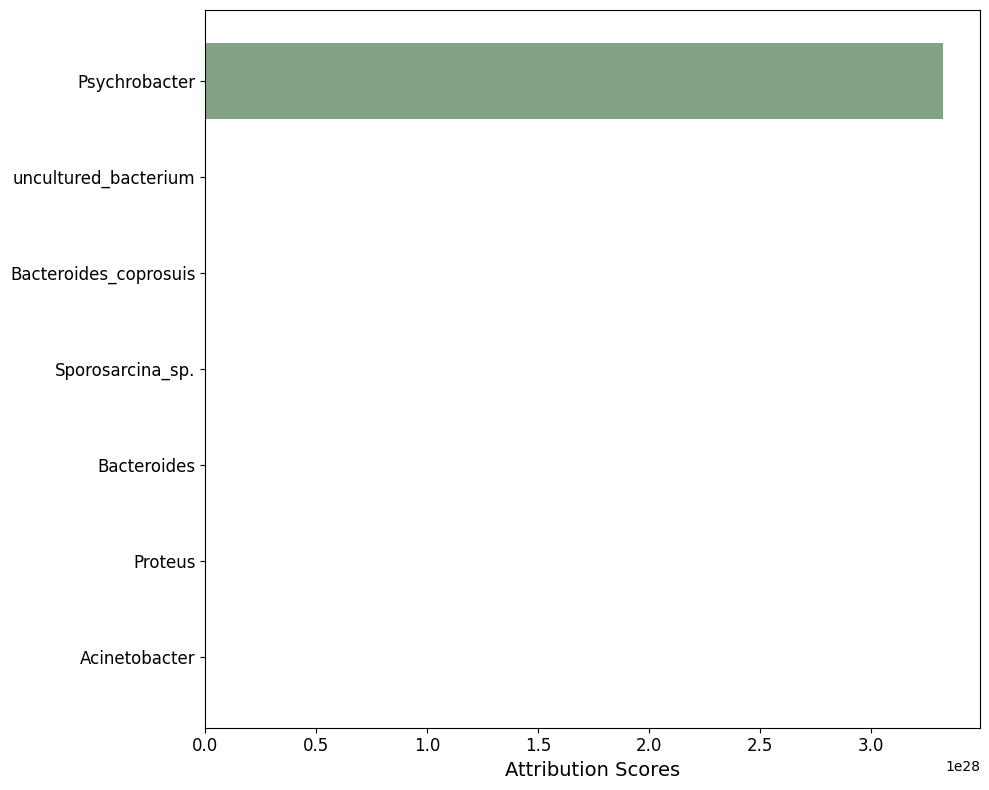

In [25]:


# Example input
top_n = 10
labels_to_plot = lbls[:top_n]
values_to_plot = vals[:top_n]

color = (0.2, # redness
         0.4, # greenness
         0.2, # blueness
         0.6 # transparency
         ) 

# # Generate N distinct colors using a colormap (e.g., tab10, viridis, etc.)
# cmap = cm.get_cmap('tab10', top_n)  # 'tab20' or 'viridis' also good options
# colors = [cmap(i) for i in range(top_n)]
#colors = [label_color_map[label] for label in labels_to_plot]

# Plot
plt.figure(figsize=(10, 8))
plt.barh(labels_to_plot, values_to_plot, color=color)
plt.gca().invert_yaxis()
plt.xlabel("Attribution Scores", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(f"{res}/all_attributions.png", dpi=600, bbox_inches='tight')
plt.show()


In [ ]:

taxon_attr = {}
for sample_id, seq_ids in all_samples_asv_importance.items():
    print(f"Sample ID: {sample_id}")
    for seq_id, importance in seq_ids.items():
        # Find the corresponding taxonomy information
        taxonomy_info = taxonomy[taxonomy['Feature ID'] == seq_id]
        if not taxonomy_info.empty:
            taxon = taxonomy_info.iloc[0]['Taxon']
            print(f"  Seq ID: {seq_id}, Importance: {importance}, Taxon: {taxon}")
            if taxon in taxon_attr:
                taxon_attr[taxon] += importance
            else:
                taxon_attr[taxon] = importance
        else:
            print(f"  Seq ID: {seq_id}, Importance: {importance}, Taxon: Not found")

In [7]:
import shap
donor_id= "D16"
your_model = WrappedModel(model).to(device)
abundance_table, train_data, test_data, embedding_path, _  = load_data(heldout=donor_id, kmer_embedding=False)

test_loader = sample_test_data(abundance_table, test_data,batch_size=4, embedding_path = embedding_path, random_vector=False) 
                
# Initialize accumulators
all_attr_embeddings = []
all_seq_ids = []
all_sample_ids = []
    # Loop through test_loader
for batch in tqdm(test_loader):
        embeddings = batch['embeddings'].to(device).requires_grad_()
        abundances = batch['abundances'].to(device).requires_grad_()
        masks = batch['masks'].to(device)
        targets = batch['outdoor_add_0'].to(device)
        sample_ids = batch['SampleID']
        seq_ids = batch['seqs_ids']
        all_seq_ids.append(seq_ids)
        all_sample_ids.append(sample_ids)
        # Baselines (here: zero baselines)
        baseline_embed = torch.zeros_like(embeddings)
        baseline_abund = torch.zeros_like(abundances)
        baseline_masks = torch.zeros_like(masks)

        inputs = (embeddings, abundances, masks)
        background = (baseline_embed, baseline_abund, baseline_masks)


        explainer = shap.GradientExplainer(your_model, background)

        shap_result = explainer(inputs) #or some subset of X or test data or whatever
        shap_values = shap_result.values # attributions
        shap_data = shap_result.data # parrot of the predicted value being explained

        print(shap_values.shape) #-> (batch_size, X.shape[1], your_model[X].shape[1]) <- at least if your inputs and outputsare flat vectors

# attribution_of_input_feature_i_to_output_target_j_for_sample_s = shape_values[s,i,j]

# print(type(shap_values)) # numpy array

Subsampling data False
In data loader  (255, 33)


  0%|          | 0/9 [00:00<?, ?it/s]

Inputs received: (tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 

  0%|          | 0/9 [00:00<?, ?it/s]


AttributeError: 'tuple' object has no attribute 'shape'

Subsampling data False
In data loader  (402, 35)


  0%|          | 0/9 [00:00<?, ?it/s]

True torch.Size([4, 63, 768])


 22%|██▏       | 2/9 [00:03<00:10,  1.53s/it]

True torch.Size([4, 85, 768])
True torch.Size([4, 77, 768])


...

True torch.Size([4, 68, 768])
True torch.Size([4, 89, 768])


 78%|███████▊  | 7/9 [00:04<00:00,  3.80it/s]

True torch.Size([4, 82, 768])
True torch.Size([4, 72, 768])


100%|██████████| 9/9 [00:04<00:00,  1.96it/s]

True torch.Size([4, 99, 768])
True torch.Size([3, 72, 768])


In [10]:
len(all_seq_ids[0][0])

63

In [12]:
all_attr_embeddings[0].shape

torch.Size([4, 63, 768])

In [11]:
len(all_seq_ids)

9

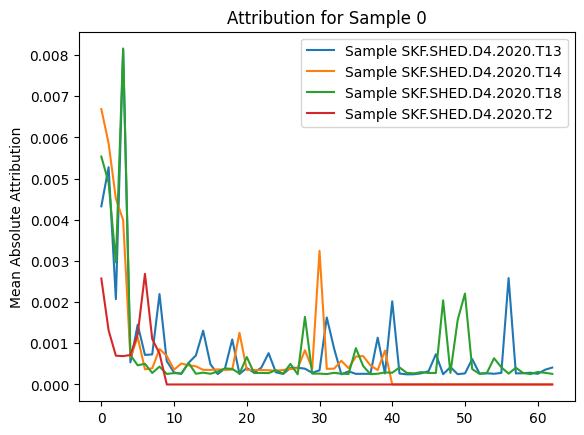

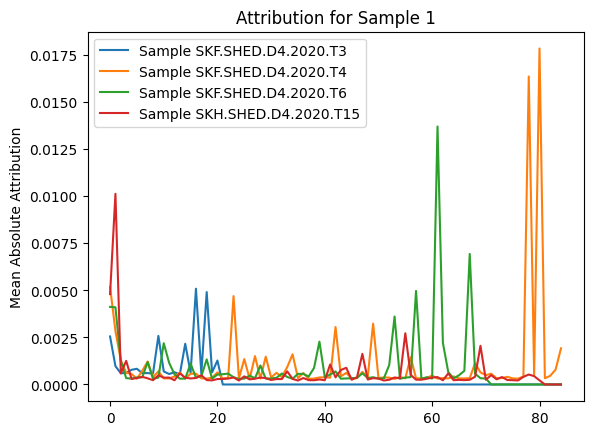

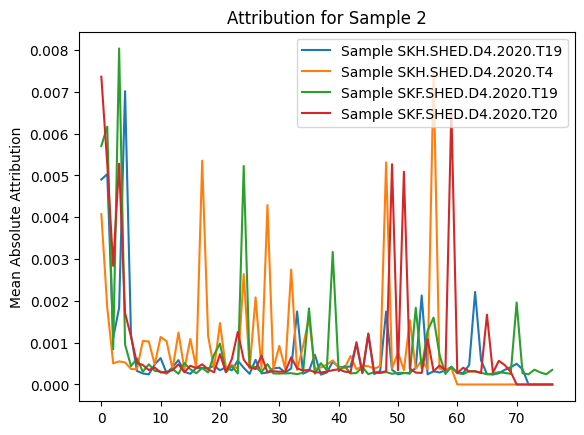

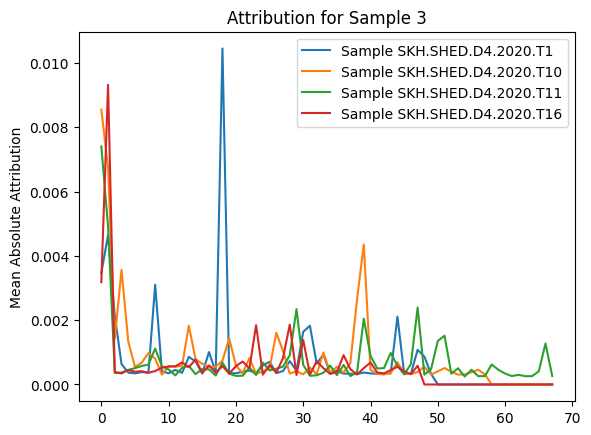

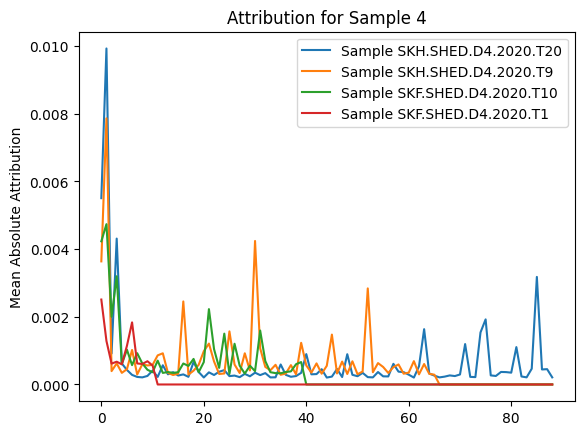

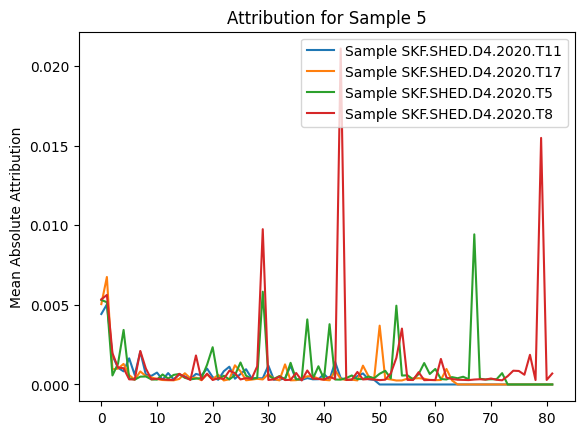

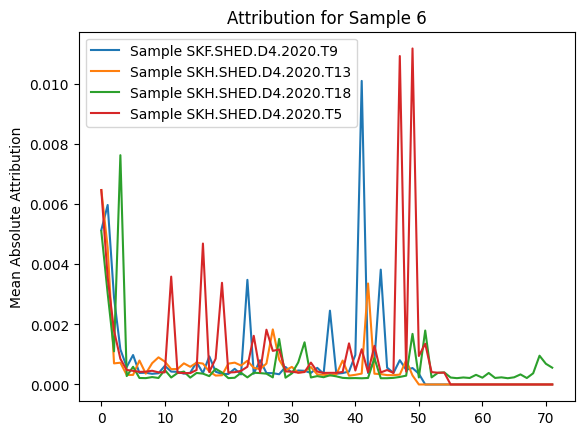

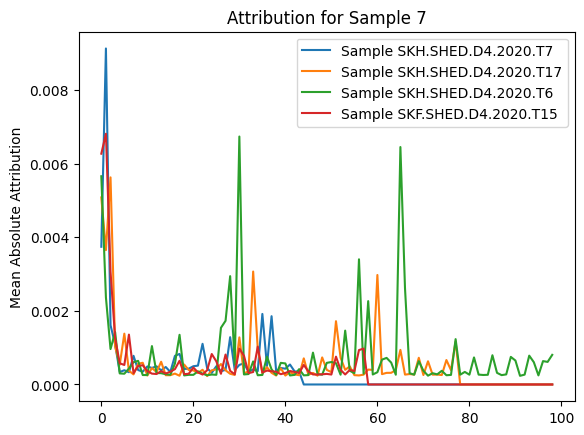

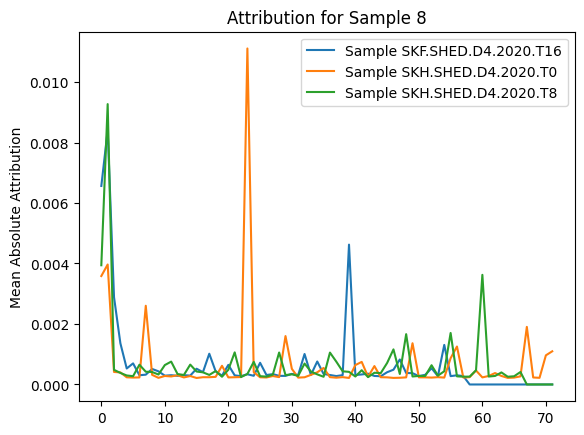

In [15]:
per_sample_asv_importance = {}
for i in range(len(all_attr_embeddings)):
    sample_ids = all_sample_ids[i]
    per_batch_seq_ids = all_seq_ids[i]
    for j in range(all_attr_embeddings[i].shape[0]):
        sample_id = sample_ids[j].item()
        per_sample_asv_importance[sample_id] = per_sample_asv_importance.get(sample_id,{})
        per_sample_seq_ids = per_batch_seq_ids[j]
        attr = all_attr_embeddings[i][j].abs().mean(dim=-1).numpy()
        attr_thresh = np.max(attr) * 0.70
        for k in range(len(per_sample_seq_ids)):
            seq_id = per_sample_seq_ids[k]
            if attr[k] < attr_thresh:
                continue
            per_sample_asv_importance[sample_id][seq_id] = attr[k]
            
            # Do something with the sample_id and seq_id
            # For example, you can store them in a list or print them
            # Here, we just print them for demonstration purposes
        plt.plot(attr, label=f'Sample {sample_id}')

    plt.ylabel('Mean Absolute Attribution')
    plt.title(f'Attribution for Sample {i}')
    plt.legend()
    plt.show()
    # attr_sample = attr_embeddings[i]  # shape [65, 768]
    # mean_importance_per_token = attr_sample.abs().mean(dim=-1)  # shape [65]


In [16]:
per_sample_asv_importance

{'SKF.SHED.D4.2020.T13': {'21610dcbd05af4529071c39e2997cf17': 0.008136681},
 'SKF.SHED.D4.2020.T14': {'3073690a8233475dcf5f6d739def1bb5': 0.006689859,
  '720bbb0411edd2b97a8cc3d66e3b47e0': 0.0058591105},
 'SKF.SHED.D4.2020.T18': {'21610dcbd05af4529071c39e2997cf17': 0.008162421},
 'SKF.SHED.D4.2020.T2': {'5ccd30281011c170e7e836bc752205e6': 0.0025737185,
  '04524511556ae43c41266c364d115459': 0.0026877865},
 'SKF.SHED.D4.2020.T3': {'419fd81c2cdac1a5d38831e40efdc3b0': 0.005087671,
  'c9f3278443d8ca1fe052cd9ec91428f2': 0.0049089543},
 'SKF.SHED.D4.2020.T4': {'e708751e62639cc0951c413f92ea7620': 0.016365675,
  'af447f79eafcbd7e31e18eaf72dc845d': 0.017853744},
 'SKF.SHED.D4.2020.T6': {'af447f79eafcbd7e31e18eaf72dc845d': 0.013706363},
 'SKH.SHED.D4.2020.T15': {'21610dcbd05af4529071c39e2997cf17': 0.010131349},
 'SKH.SHED.D4.2020.T19': {'7339301f770131bd35e653eda2ac5106': 0.005032615,
  '21610dcbd05af4529071c39e2997cf17': 0.007016983},
 'SKH.SHED.D4.2020.T4': {'22b3c70cdfb1714224e1bf8a6314bee9': 

In [21]:
taxonomy

,Feature ID,Taxon,Confidence
0,000106a81671b0a0cf68ed1c1cfb35c0,d__Bacteria,0.995667
1,000113846168a03b3ca0829ec1c88093,d__Bacteria; p__Planctomycetota; c__Planctomyc...,0.796448
2,0001d123420b59585627edf5a1292ae8,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.999712
3,00030dba364df8c7c5a7659e605c1597,d__Bacteria; p__Actinobacteriota; c__Thermoleo...,0.763107
4,00066b6e26368dbea2a2e5e4fc4be330,d__Bacteria; p__Chloroflexi; c__Anaerolineae; ...,0.925480
...,...,...,...
99113,fffdb7c064b803ba31e07e05604ed6fb,d__Bacteria; p__Bdellovibrionota; c__Oligoflex...,0.781375
99114,fffdda9bce195aff4cac20b115b309d6,d__Bacteria; p__Verrucomicrobiota; c__Verrucom...,0.737837
99115,fffe59c6ffc6f41f7f9e9f8ae3a5c528,d__Archaea; p__Nanoarchaeota; c__Nanoarchaeia;...,0.999983
99116,ffff0924f8ac7632d645b0ce821a6bcd,d__Bacteria; p__Desulfobacterota; c__Desulfuro...,0.925579


Sample ID: SKF.SHED.D4.2020.T13
  Seq ID: 21610dcbd05af4529071c39e2997cf17, Importance: 0.008136681281030178, Taxon: d__Bacteria; p__Firmicutes; c__Bacilli; o__Bacillales; f__Planococcaceae
Sample ID: SKF.SHED.D4.2020.T14
  Seq ID: 3073690a8233475dcf5f6d739def1bb5, Importance: 0.006689859088510275, Taxon: d__Bacteria; p__Firmicutes; c__Bacilli; o__Bacillales; f__Planococcaceae; g__Savagea; s__uncultured_bacterium
  Seq ID: 720bbb0411edd2b97a8cc3d66e3b47e0, Importance: 0.005859110504388809, Taxon: d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Vagococcaceae; g__Vagococcus
Sample ID: SKF.SHED.D4.2020.T18
  Seq ID: 21610dcbd05af4529071c39e2997cf17, Importance: 0.0081624211743474, Taxon: d__Bacteria; p__Firmicutes; c__Bacilli; o__Bacillales; f__Planococcaceae
Sample ID: SKF.SHED.D4.2020.T2
  Seq ID: 5ccd30281011c170e7e836bc752205e6, Importance: 0.00257371854968369, Taxon: d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Pseudomonadales; f__Moraxellaceae; g__Psychr

In [25]:
imp_species = []
for key, value in taxon_attr.items():
    print(f"Taxon: {key}, Importance: {value}")
    taxons = key.split(";")
    specie = taxons[-1]
    imp_species.append((specie, value))
imp_species = sorted(imp_species, key=lambda x: x[1], reverse=True)
    

Taxon: d__Bacteria; p__Firmicutes; c__Bacilli; o__Bacillales; f__Planococcaceae, Importance: 0.009270180016756058
Taxon: d__Bacteria; p__Firmicutes; c__Bacilli; o__Bacillales; f__Planococcaceae; g__Savagea; s__uncultured_bacterium, Importance: 0.00656386511400342
Taxon: d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Vagococcaceae; g__Vagococcus, Importance: 0.00627167709171772
Taxon: d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Pseudomonadales; f__Moraxellaceae; g__Psychrobacter; s__Psychrobacter_pulmonis, Importance: 0.005658418405801058
Taxon: d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Cardiobacteriales; f__Wohlfahrtiimonadaceae; g__Ignatzschineria; s__Ignatzschineria_sp., Importance: 0.005704781506210566
Taxon: d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Oceanospirillales; f__Halomonadaceae; g__Zymobacter; s__Zymobacter_palmae, Importance: 0.015483853407204151
Taxon: d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavoba

In [26]:
imp_species

[(' g__Clostridium_sensu_stricto_1', 0.021099942),
 (' g__Fusobacterium', 0.016365675),
 (' s__Zymobacter_palmae', 0.015483853),
 (' s__uncultured_bacterium', 0.0111093195),
 (' g__Lactobacillus', 0.010933206),
 (' s__uncultured_bacterium', 0.01010507),
 (' f__Planococcaceae', 0.00927018),
 (' g__Sporosarcina', 0.008408184),
 (' s__Fructobacillus_fructosus', 0.00673789),
 (' s__Leuconostoc_mesenteroides', 0.0065791137),
 (' s__uncultured_bacterium', 0.006563865),
 (' g__Vagococcus', 0.006271677),
 (' s__Ignatzschineria_sp.', 0.0057047815),
 (' s__Psychrobacter_pulmonis', 0.0056584184),
 (' g__Dysgonomonas', 0.0052689766),
 (' g__Acinetobacter', 0.0050832005),
 (' g__Pseudomonas', 0.0050447886),
 (' g__Proteus', 0.005025632),
 (' s__Myroides_odoratus', 0.0049089543),
 (' s__Wohlfahrtiimonas_chitiniclastica', 0.004425176),
 (' g__Ignatzschineria', 0.0018349732)]

In [ ]:
# Concatenate all attribution tensors
all_attr_embeddings = torch.cat(all_attr_embeddings, dim=0)  # shape: (N, D)

# Aggregate: mean absolute attribution per feature dimension
mean_attr = torch.mean(torch.abs(all_attr_embeddings), dim=0).numpy()

# Get top k dimensions
top_k = 10
top_indices = np.argsort(mean_attr)[-top_k:][::-1]
top_values = mean_attr[top_indices]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(range(top_k), top_values, tick_label=[f"Dim {i}" for i in top_indices])
plt.title("Top Embedding Dimensions by Mean |DeepSHAP Attribution|")
plt.xlabel("Embedding Dimension")
plt.ylabel("Mean Absolute Attribution")
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
rf_res = pd.read_csv('indoor_outdoor_output_2.csv')

In [3]:
rf_res.columns

Index(['SampleID', 'BarcodeID', 'sequencing_run', 'extraction_plate',
       'well_id', 'barcode', 'sequenced?', 'collected?', 'collected_by',
       'collection_date', 'megyesi_score', 'DonorID', 'stafs_accession',
       'indoor_outdoor', 'sample_type', 'body_site', 'swube?', 'replicate',
       'control?', 'sample_location', 'season', 'start_year',
       'days_since_placement', 'sampling_timepoint', 'autopsy?',
       'donor_storage', 'donor_storage_days', 'tot_mas', 'approx_age',
       'height', 'sex', 'geo_loc_me', 'latitude', 'longitude',
       'avg_percent_humidity', 'total_precipitation_in', 'temp_prob',
       'indoor_add_0', 'predicted_indoor_add_0', 'outdoor_add_0', 'temp_c',
       'temperature_station', 'insect_activity', 'flies', 'maggots', 'beetles',
       'ants', 'scavenging', 'notes', 'env', 'facility', 'predicted_add'],
      dtype='object')

In [5]:
np.mean(np.abs(rf_res["outdoor_add_0"] - rf_res["predicted_add"]))

51.562120370164145